<div style="background-color:#EFF5FF; padding:22px; border-radius:10px; border-left:8px solid #0047AB;">
<h1 style="margin-bottom:0;"><b>Machine Learning II</b></h1>
<h3><b>Customer Segmentation — EDA & Preprocessing</b></h3>
<p style="font-size:15px; margin-top:14px;">
This notebook cleans the <code>customer_info</code> dataset and prepares it for clustering.
We inspect data quality, fix what is clearly wrong, engineer behavioural features,
impute missing values with KNN and export two aligned files: one for modelling and
one in original units for interpreting segments later.
Reusable logic lives in <code>utils_eda.py</code> so the notebook stays clean.
</p></div>

<div style="background-color:#EFF5FF; padding:18px; border-radius:10px; border-left:8px solid #0047AB;">
<h2 style="margin-top:0;"><b>Index</b></h2>
<ol>
<li>Imports &amp; Loading</li>
<li>Data Quality Inspection</li>
<li>Data Cleaning</li>
<li>Feature Engineering — Demographics</li>
<li>KNN Imputation</li>
<li>Feature Engineering — Spend &amp; Lifecycle</li>
<li>Outlier Treatment</li>
<li>Distributions &amp; Correlations</li>
<li>Export</li>
</ol></div>

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #0047AB;"><h3><b>1. Imports &amp; Loading</b></h3></div>

In [1]:
%load_ext autoreload
%autoreload 2

import os
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import importlib
import utils_eda as utils
importlib.reload(utils)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
pd.set_option("display.max_columns", None)
BLUE = "#1B4F72"

assert hasattr(utils, "build_clustering_dataset"), "Reload utils_eda.py"
print("utils_eda loaded correctly.")

utils_eda loaded correctly.


In [2]:
candidates = ["customer_info.csv", "../datasets/customer_info.csv", "datasets/customer_info.csv"]
DATA_PATH  = next((p for p in candidates if os.path.exists(p)), candidates[0])

ci          = pd.read_csv(DATA_PATH)
ci_original = ci.copy()
print(f"Loaded {DATA_PATH} | shape: {ci.shape}")
ci.head()

Loaded ../datasets/customer_info.csv | shape: (33038, 25)


,customer_id,customer_name,customer_gender,customer_birthdate,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_electronics,typical_hour,lifetime_spend_vegetables,lifetime_spend_nonalcohol_drinks,lifetime_spend_alcohol_drinks,lifetime_spend_meat,lifetime_spend_fish,lifetime_spend_hygiene,lifetime_spend_videogames,lifetime_spend_petfood,lifetime_total_distinct_products,percentage_of_products_bought_promotion,year_first_transaction,loyalty_card_number,latitude,longitude
0,3,Bsc. Crystal Kitchens,female,02/12/1970 01:36 PM,1.0,1.0,1.0,3.0,11731.0,4553.0,NaN,373.0,323.0,177.0,28.0,213.0,552.0,256.0,384.0,189.0,0.631599,2020.0,1.0,38.794428,-9.215739
1,4,Bsc. Glenda Bauman,female,11/13/1975 06:58 PM,1.0,0.0,0.0,2.0,13694.0,963.0,NaN,2012.0,533.0,95.0,43.0,15.0,1880.0,333.0,665.0,130.0,0.149890,2013.0,1.0,38.751711,-9.179611
2,5,Msc. Antonio Campbell,male,09/10/1971 10:07 AM,0.0,0.0,NaN,2.0,12407.0,0.0,11.0,555.0,101.0,118.0,1265.0,273.0,507.0,101.0,222.0,81.0,0.069126,2005.0,NaN,38.780678,-9.160656
3,7,John Kelling,male,10/23/1982 11:20 AM,0.0,0.0,2.0,1.0,7493.0,1105.0,18.0,84.0,757.0,1133.0,972.0,1083.0,485.0,1656.0,184.0,92.0,0.253609,2021.0,1.0,38.739548,-9.148679
4,8,Arthur Dematteo,male,08/04/1969 10:22 PM,0.0,0.0,3.0,1.0,9187.0,10841.0,17.0,380.0,592.0,718.0,1068.0,1015.0,297.0,1258.0,441.0,6.0,0.186569,2021.0,1.0,38.733071,-9.188188


<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #0047AB;"><h3><b>2. Data Quality Inspection</b></h3></div>

<div style="background-color:#F9FCFF; padding:16px; border-radius:10px;">First look at types, missing values and ranges. This flags the issues we fix next: future transaction years, out-of-range promotion percentages, a constant loyalty column and several sparse spend columns.</div>

In [3]:
ci.info(memory_usage="deep")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33038 entries, 0 to 33037
Data columns (total 25 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   customer_id                              33038 non-null  int64  
 1   customer_name                            33038 non-null  object 
 2   customer_gender                          33038 non-null  object 
 3   customer_birthdate                       32873 non-null  object 
 4   kids_home                                32708 non-null  float64
 5   teens_home                               32708 non-null  float64
 6   number_complaints                        32377 non-null  float64
 7   distinct_stores_visited                  32708 non-null  float64
 8   lifetime_spend_groceries                 33038 non-null  float64
 9   lifetime_spend_electronics               32377 non-null  float64
 10  typical_hour                             32377

In [4]:
missing = utils.get_missing_percent(ci)
missing[missing["Missing_Percent"] > 0]

,Column,Missing_Percent
22,loyalty_card_number,39.67
15,lifetime_spend_fish,3.00
9,lifetime_spend_electronics,2.00
17,lifetime_spend_videogames,2.00
14,lifetime_spend_meat,2.00
11,lifetime_spend_vegetables,2.00
10,typical_hour,2.00
18,lifetime_spend_petfood,2.00
6,number_complaints,2.00
7,distinct_stores_visited,1.00


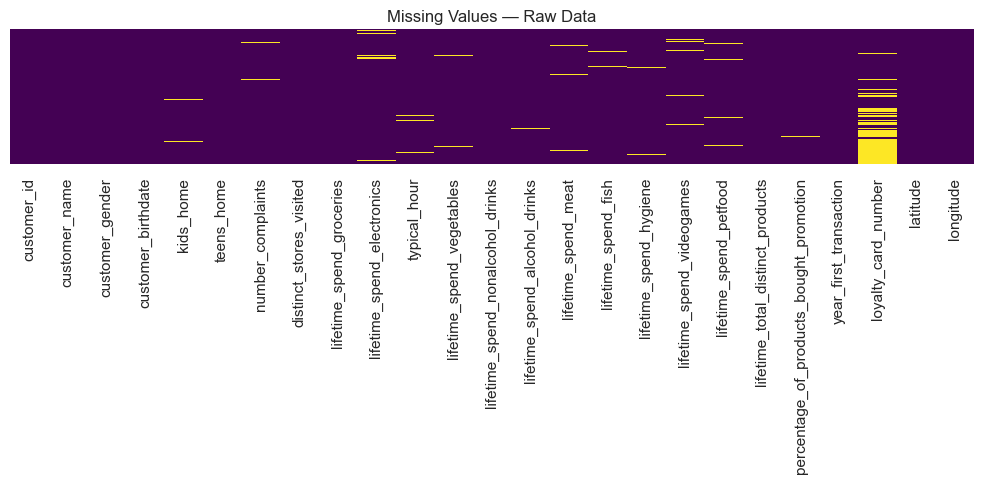

In [5]:
utils.plot_missing_heatmap(ci, "Missing Values — Raw Data")

In [6]:
ci.describe().T

,count,mean,std,min,25%,50%,75%,max
customer_id,33038.0,19974.265785,11538.538632,3.000000,9985.250000,19951.500000,29964.750000,40000.000000
kids_home,32708.0,1.116118,1.150186,0.000000,0.000000,1.000000,1.000000,8.000000
teens_home,32708.0,0.898893,0.962924,0.000000,0.000000,1.000000,1.000000,6.000000
number_complaints,32377.0,0.930846,0.894658,0.000000,0.000000,1.000000,1.000000,7.000000
distinct_stores_visited,32708.0,3.167941,1.674114,1.000000,2.000000,3.000000,4.000000,10.000000
lifetime_spend_groceries,33038.0,16306.227798,11985.903518,0.000000,8647.000000,13002.500000,20807.000000,104670.000000
lifetime_spend_electronics,32377.0,2763.080088,3453.191495,0.000000,579.000000,1470.000000,3745.000000,35299.000000
typical_hour,32377.0,12.659388,4.854708,6.000000,8.000000,12.000000,16.000000,23.000000
lifetime_spend_vegetables,32377.0,727.223801,654.633087,0.000000,224.000000,471.000000,1074.000000,3337.000000
lifetime_spend_nonalcohol_drinks,33038.0,464.352776,275.767976,0.000000,241.000000,421.000000,640.000000,2180.000000


In [7]:
print("Transaction years above the current year:")
print(sorted(ci.loc[ci["year_first_transaction"] > pd.Timestamp.now().year,
                     "year_first_transaction"].dropna().unique()))
print("\nPromotion percentage range:",
      ci["percentage_of_products_bought_promotion"].min(),
      "to", ci["percentage_of_products_bought_promotion"].max())
print("Loyalty card distinct values:", ci["loyalty_card_number"].dropna().unique()[:5])

Transaction years above the current year:
[np.float64(2027.0), np.float64(2028.0), np.float64(2029.0)]

Promotion percentage range: -1.2749404207754256 to 1.0
Loyalty card distinct values: [1.]


<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #0047AB;"><h3><b>3. Data Cleaning</b></h3></div>

<div style="background-color:#F9FCFF; padding:16px; border-radius:10px;">We turn impossible values into <code>NaN</code> instead of dropping rows. The project requires every customer in the final file, so future years and bad promotion percentages are flagged as missing and recovered by KNN later.</div>

In [8]:
ci_clean    = ci.copy()
current_year = pd.Timestamp.now().year

future = ci_clean["year_first_transaction"] > current_year
ci_clean.loc[future, "year_first_transaction"] = np.nan
print(f"Future years flagged: {future.sum()}")

bad_promo = ((ci_clean["percentage_of_products_bought_promotion"] < 0) |
             (ci_clean["percentage_of_products_bought_promotion"] > 1))
ci_clean.loc[bad_promo, "percentage_of_products_bought_promotion"] = np.nan
print(f"Invalid promotion percentages flagged: {bad_promo.sum()}")

Future years flagged: 991
Invalid promotion percentages flagged: 1755


In [9]:
ci_clean["customer_birthdate"] = pd.to_datetime(
    ci_clean["customer_birthdate"], format="%m/%d/%Y %I:%M %p", errors="coerce")
ci_clean["typical_hour"] = pd.to_numeric(ci_clean["typical_hour"], errors="coerce")
ci_clean = utils.apply_cyclic_transformation(ci_clean, "typical_hour", max_val=24)
ci_clean[["typical_hour", "typical_hour_sin", "typical_hour_cos"]].head()

,typical_hour,typical_hour_sin,typical_hour_cos
0,NaN,NaN,NaN
1,NaN,NaN,NaN
2,11.0,0.258819,-9.659258e-01
3,18.0,-1.000000,-1.836970e-16
4,17.0,-0.965926,-2.588190e-01


In [10]:
print("Capping bounded features:")
ci_clean = utils.cap_bounded_features(ci_clean)

for col in ["kids_home", "teens_home", "number_complaints"]:
    ci_clean[col] = ci_clean[col].fillna(0)

ci_clean.rename(columns={"loyalty_card_number": "customer_loyalty_flag"}, inplace=True)
ci_clean["customer_loyalty_flag"] = (
    ci_clean["customer_loyalty_flag"].fillna(0).apply(lambda x: 1 if x != 0 else 0))
ci_clean["customer_loyalty_flag"].value_counts()

Capping bounded features:
  kids_home: 1486 values capped at 3
  teens_home: 2098 values capped at 2
  number_complaints: 1368 values capped at 2
  distinct_stores_visited: 853 values capped at 6


customer_loyalty_flag
1    19932
0    13106
Name: count, dtype: int64

In [11]:
protected = ["customer_id", "customer_loyalty_flag", "is_male", "education_level"]
before    = ci_clean.shape[1]
ci_clean  = utils.remove_semi_constant_features(ci_clean, threshold=0.99, exclude_cols=protected)
print(f"Columns: {before} → {ci_clean.shape[1]}")

Semi-constant columns removed (≥99%): []
Columns: 27 → 27


<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #0047AB;"><h3><b>4. Feature Engineering — Demographics</b></h3></div>

In [12]:
today = pd.Timestamp.now().normalize()
ci_clean["customer_age"] = (today - ci_clean["customer_birthdate"]).dt.days // 365
impossible = (ci_clean["customer_age"] < 16) | (ci_clean["customer_age"] > 100)
ci_clean.loc[impossible, "customer_age"] = np.nan
ci_clean.drop(columns=["customer_birthdate"], inplace=True)
print(f"Ages flagged as impossible: {impossible.sum()}")

Ages flagged as impossible: 0


In [13]:
# education_level encoded as years of formal education (12/15/17/22)
# so it carries ~10x more variance than an ordinal 0-3 scale
education = ci_clean.apply(utils.get_education_info, axis=1)
ci_clean["education_level"] = education[0].astype(int)

ci_clean["is_male"] = ci_clean["customer_gender"].map({"male": 1, "female": 0})
ci_clean.drop(columns=["customer_gender", "customer_name"], inplace=True, errors="ignore")
ci_clean["education_level"].value_counts().sort_index()

education_level
12    17731
15     5154
17     5057
22     5096
Name: count, dtype: int64

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #0047AB;"><h3><b>5. KNN Imputation</b></h3></div>

<div style="background-color:#F9FCFF; padding:16px; border-radius:10px;">We move <code>customer_id</code> to the index first so the imputer never treats two customers as similar just because their IDs are close. Clean binary flags are excluded from the distance calculation.</div>

,Missing Count,Percentage (%)
percentage_of_products_bought_promotion,2085,6.31
lifetime_spend_fish,991,3.00
year_first_transaction,991,3.00
lifetime_spend_electronics,661,2.00
typical_hour,661,2.00
lifetime_spend_vegetables,661,2.00
lifetime_spend_meat,661,2.00
lifetime_spend_videogames,661,2.00
lifetime_spend_petfood,661,2.00
typical_hour_sin,661,2.00


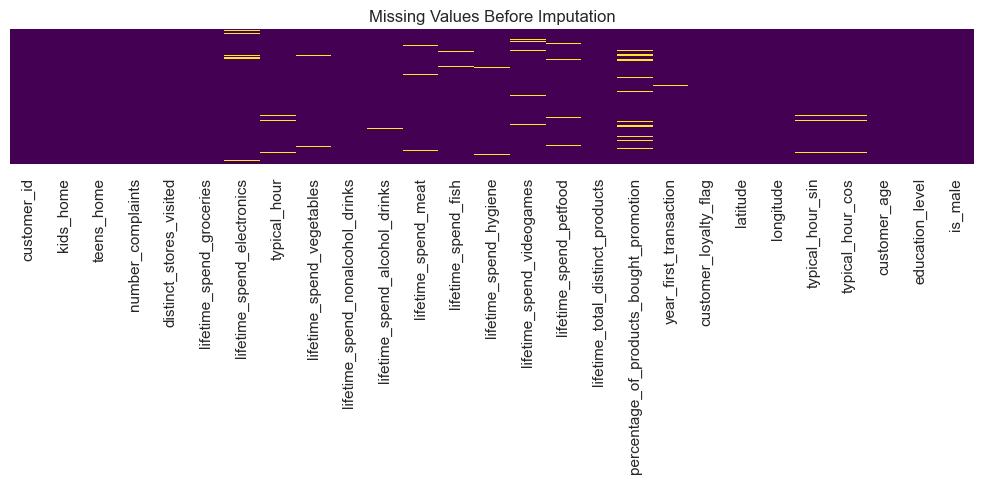

In [14]:
display(utils.get_missing_report(ci_clean))
utils.plot_missing_heatmap(ci_clean, "Missing Values Before Imputation")

In [15]:
ci_clean  = ci_clean.set_index("customer_id", drop=True)
ci_before = ci_clean.copy()

exclude  = [c for c in ["customer_loyalty_flag", "is_male", "education_level"]
            if c in ci_clean.columns]
ci_clean = utils.apply_knn_imputation(ci_clean, n_neighbors=5, exclude_cols=exclude)

imputed  = [c for c in ci_clean.select_dtypes(include=[np.number]).columns
            if c not in exclude]
utils.validate_imputation(ci_before, ci_clean, imputed)
print("Remaining missing values:", ci_clean.isna().sum().sum())

Imputation warnings:
  - longitude max grew from -9.04 to -9.04
Remaining missing values: 0


In [16]:
to_int = ["kids_home", "teens_home", "number_complaints", "distinct_stores_visited",
          "lifetime_total_distinct_products", "year_first_transaction",
          "customer_loyalty_flag", "education_level", "is_male"]
for col in to_int:
    if col in ci_clean.columns:
        ci_clean[col] = ci_clean[col].round().astype("Int64")

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #0047AB;"><h3><b>6. Feature Engineering — Spend &amp; Lifecycle</b></h3></div>

In [17]:
ci_clean["tenure"]         = current_year - ci_clean["year_first_transaction"]
ci_clean["total_children"] = ci_clean["kids_home"] + ci_clean["teens_home"]

# Group electronics + videogames → technology (more cohesive category)
ci_clean["lifetime_spend_technology"] = (
    ci_clean["lifetime_spend_electronics"] + ci_clean["lifetime_spend_videogames"])
ci_clean.drop(columns=["lifetime_spend_electronics", "lifetime_spend_videogames"],
              inplace=True)

print("\nCapping spend outliers (1.75 × IQR):")
ci_clean = utils.cap_spend_outliers(ci_clean, iqr_multiplier=1.75)


Capping spend outliers (1.75 × IQR):
  lifetime_spend_groceries: 1441 values capped at 42087
  lifetime_spend_vegetables: 87 values capped at 2552
  lifetime_spend_nonalcohol_drinks: 169 values capped at 1338
  lifetime_spend_alcohol_drinks: 471 values capped at 2097
  lifetime_spend_meat: 191 values capped at 2173
  lifetime_spend_fish: 139 values capped at 2228
  lifetime_spend_hygiene: 568 values capped at 2442
  lifetime_spend_petfood: 263 values capped at 798
  lifetime_spend_technology: 2068 values capped at 10113


In [18]:
# Share-of-wallet: compare customers by WHAT they buy, not HOW MUCH
# (a big and a small spender with the same category mix look alike)
spend_cols = ["lifetime_spend_groceries", "lifetime_spend_vegetables",
              "lifetime_spend_nonalcohol_drinks", "lifetime_spend_alcohol_drinks",
              "lifetime_spend_meat", "lifetime_spend_fish", "lifetime_spend_hygiene",
              "lifetime_spend_petfood", "lifetime_spend_technology"]

ci_clean["total_spend"] = ci_clean[spend_cols].sum(axis=1)
for col in spend_cols:
    ci_clean[col.replace("lifetime_spend_", "pct_spend_")] = np.where(
        ci_clean["total_spend"] > 0, ci_clean[col] / ci_clean["total_spend"], 0)

ci_clean["log_total_spend"] = np.log1p(np.clip(ci_clean["total_spend"], 0, None))
ci_clean = ci_clean.drop(columns=spend_cols + ["total_spend"])
print("Spend features:", [c for c in ci_clean.columns if c.startswith("pct_spend_")])

Spend features: ['pct_spend_groceries', 'pct_spend_vegetables', 'pct_spend_nonalcohol_drinks', 'pct_spend_alcohol_drinks', 'pct_spend_meat', 'pct_spend_fish', 'pct_spend_hygiene', 'pct_spend_petfood', 'pct_spend_technology']


<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #0047AB;"><h3><b>7. Outlier Treatment</b></h3></div>

<div style="background-color:#F9FCFF; padding:16px; border-radius:10px;">We <b>cap</b> extreme values with the 3.0 × IQR rule rather than deleting rows, keeping every customer in the final file. Boxplots before and after show the effect.</div>

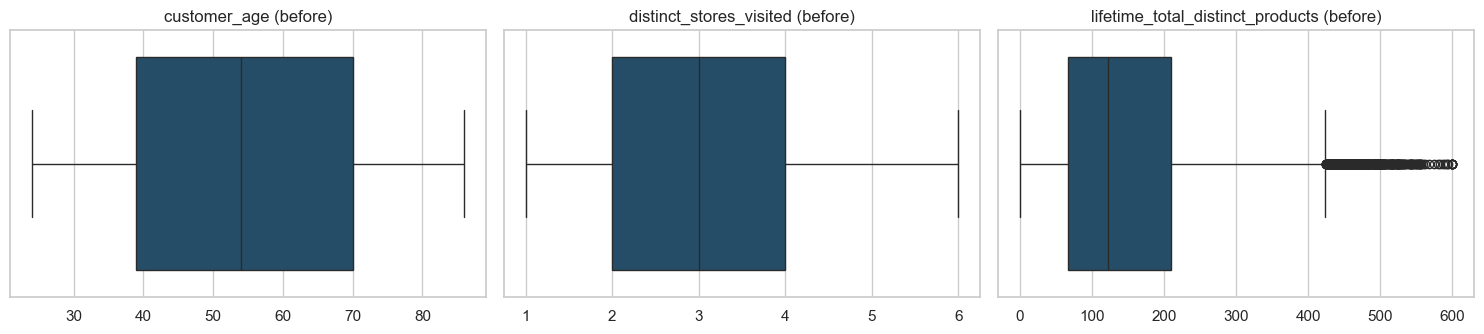

In [19]:
outlier_cols = [c for c in ["customer_age", "distinct_stores_visited",
                             "lifetime_total_distinct_products"] if c in ci_clean.columns]
utils.plot_boxplots(ci_clean, outlier_cols, title_suffix=" (before)")

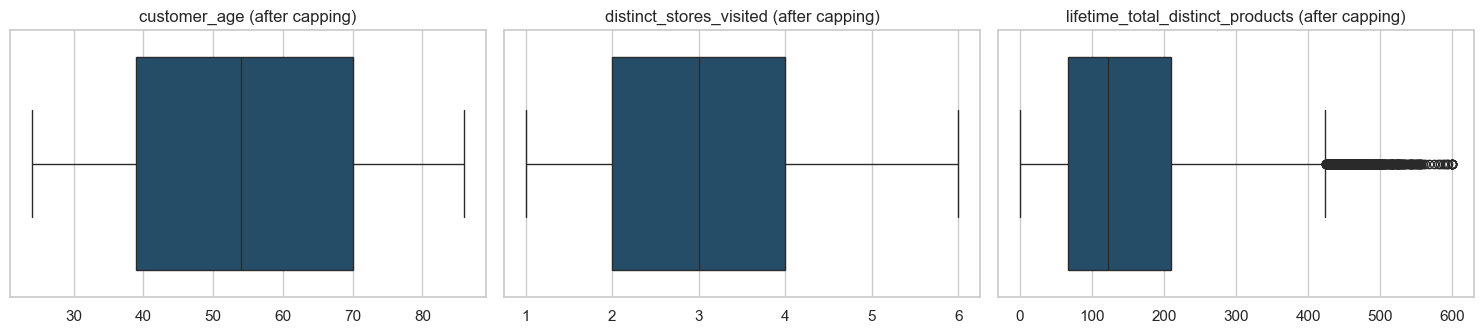

In [20]:
ci_clean = utils.handle_extreme_outliers(ci_clean, outlier_cols, strategy="cap")
utils.plot_boxplots(ci_clean, outlier_cols, title_suffix=" (after capping)")

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #0047AB;"><h3><b>8. Distributions &amp; Correlations</b></h3></div>

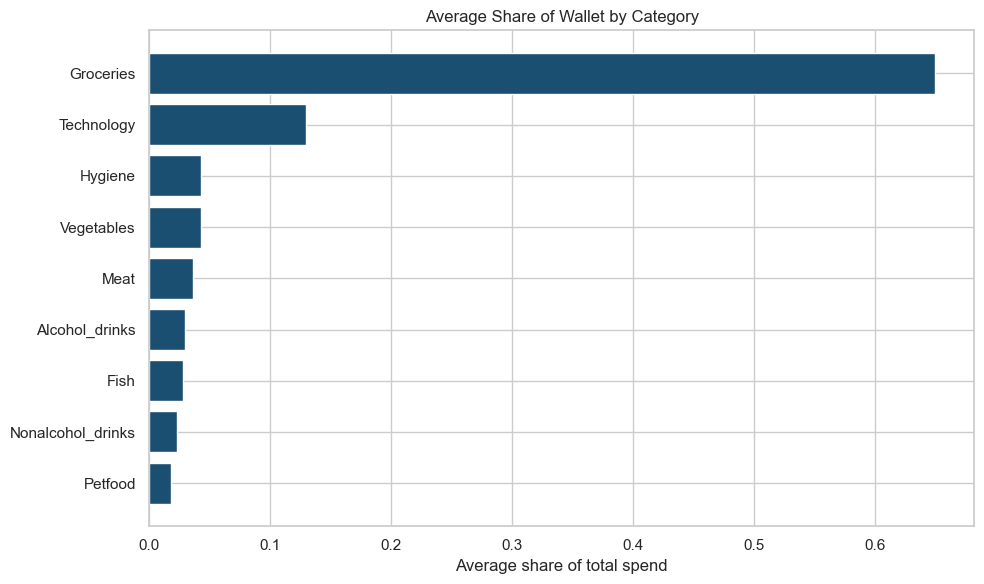

In [21]:
utils.plot_spend_breakdown(ci_clean)

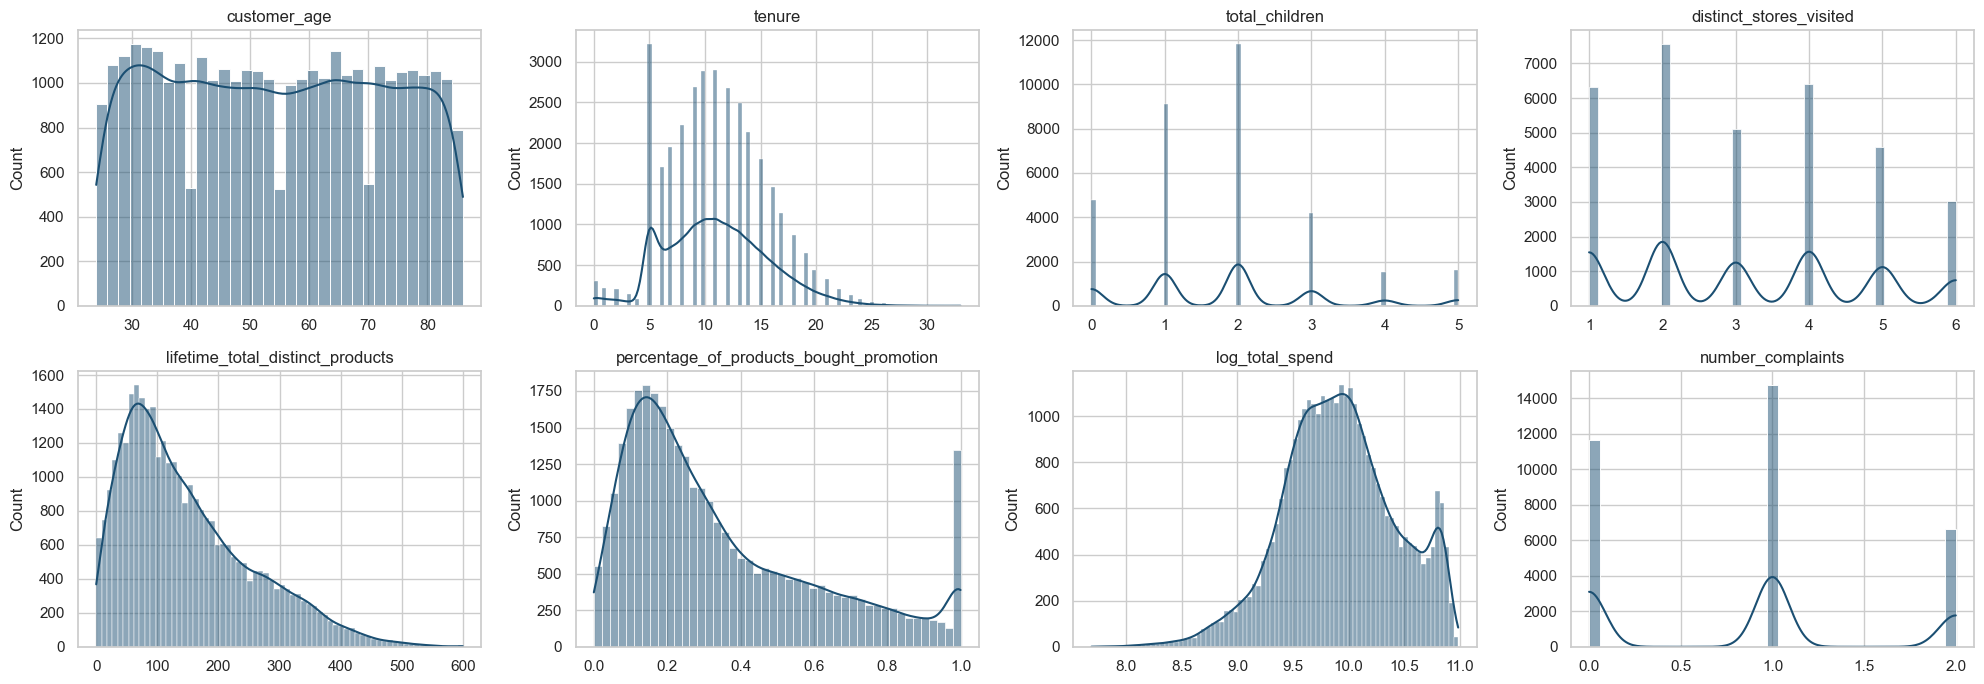

In [22]:
dist_cols = ["customer_age", "tenure", "total_children", "distinct_stores_visited",
             "lifetime_total_distinct_products", "percentage_of_products_bought_promotion",
             "log_total_spend", "number_complaints"]
utils.plot_numeric_distributions(ci_clean, dist_cols, ncols=4)

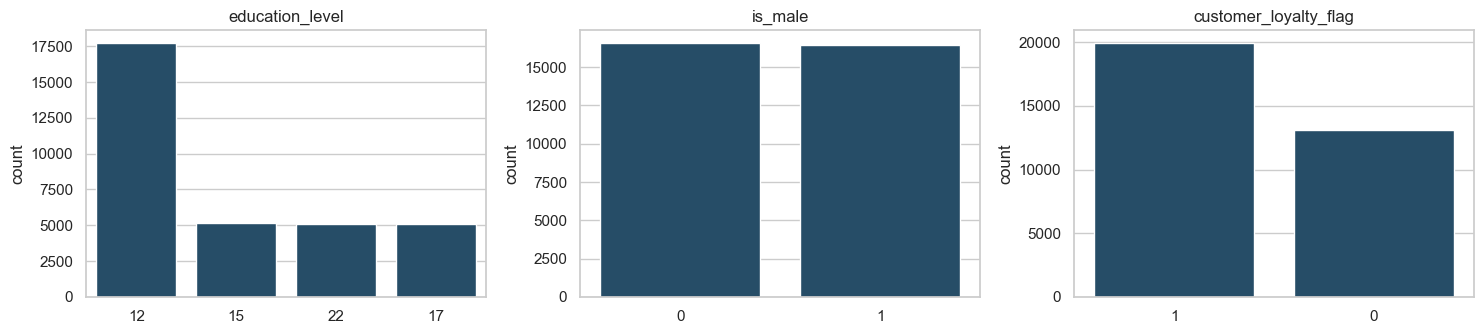

In [23]:
utils.plot_categorical_counts(ci_clean,
    ["education_level", "is_male", "customer_loyalty_flag"], ncols=3)

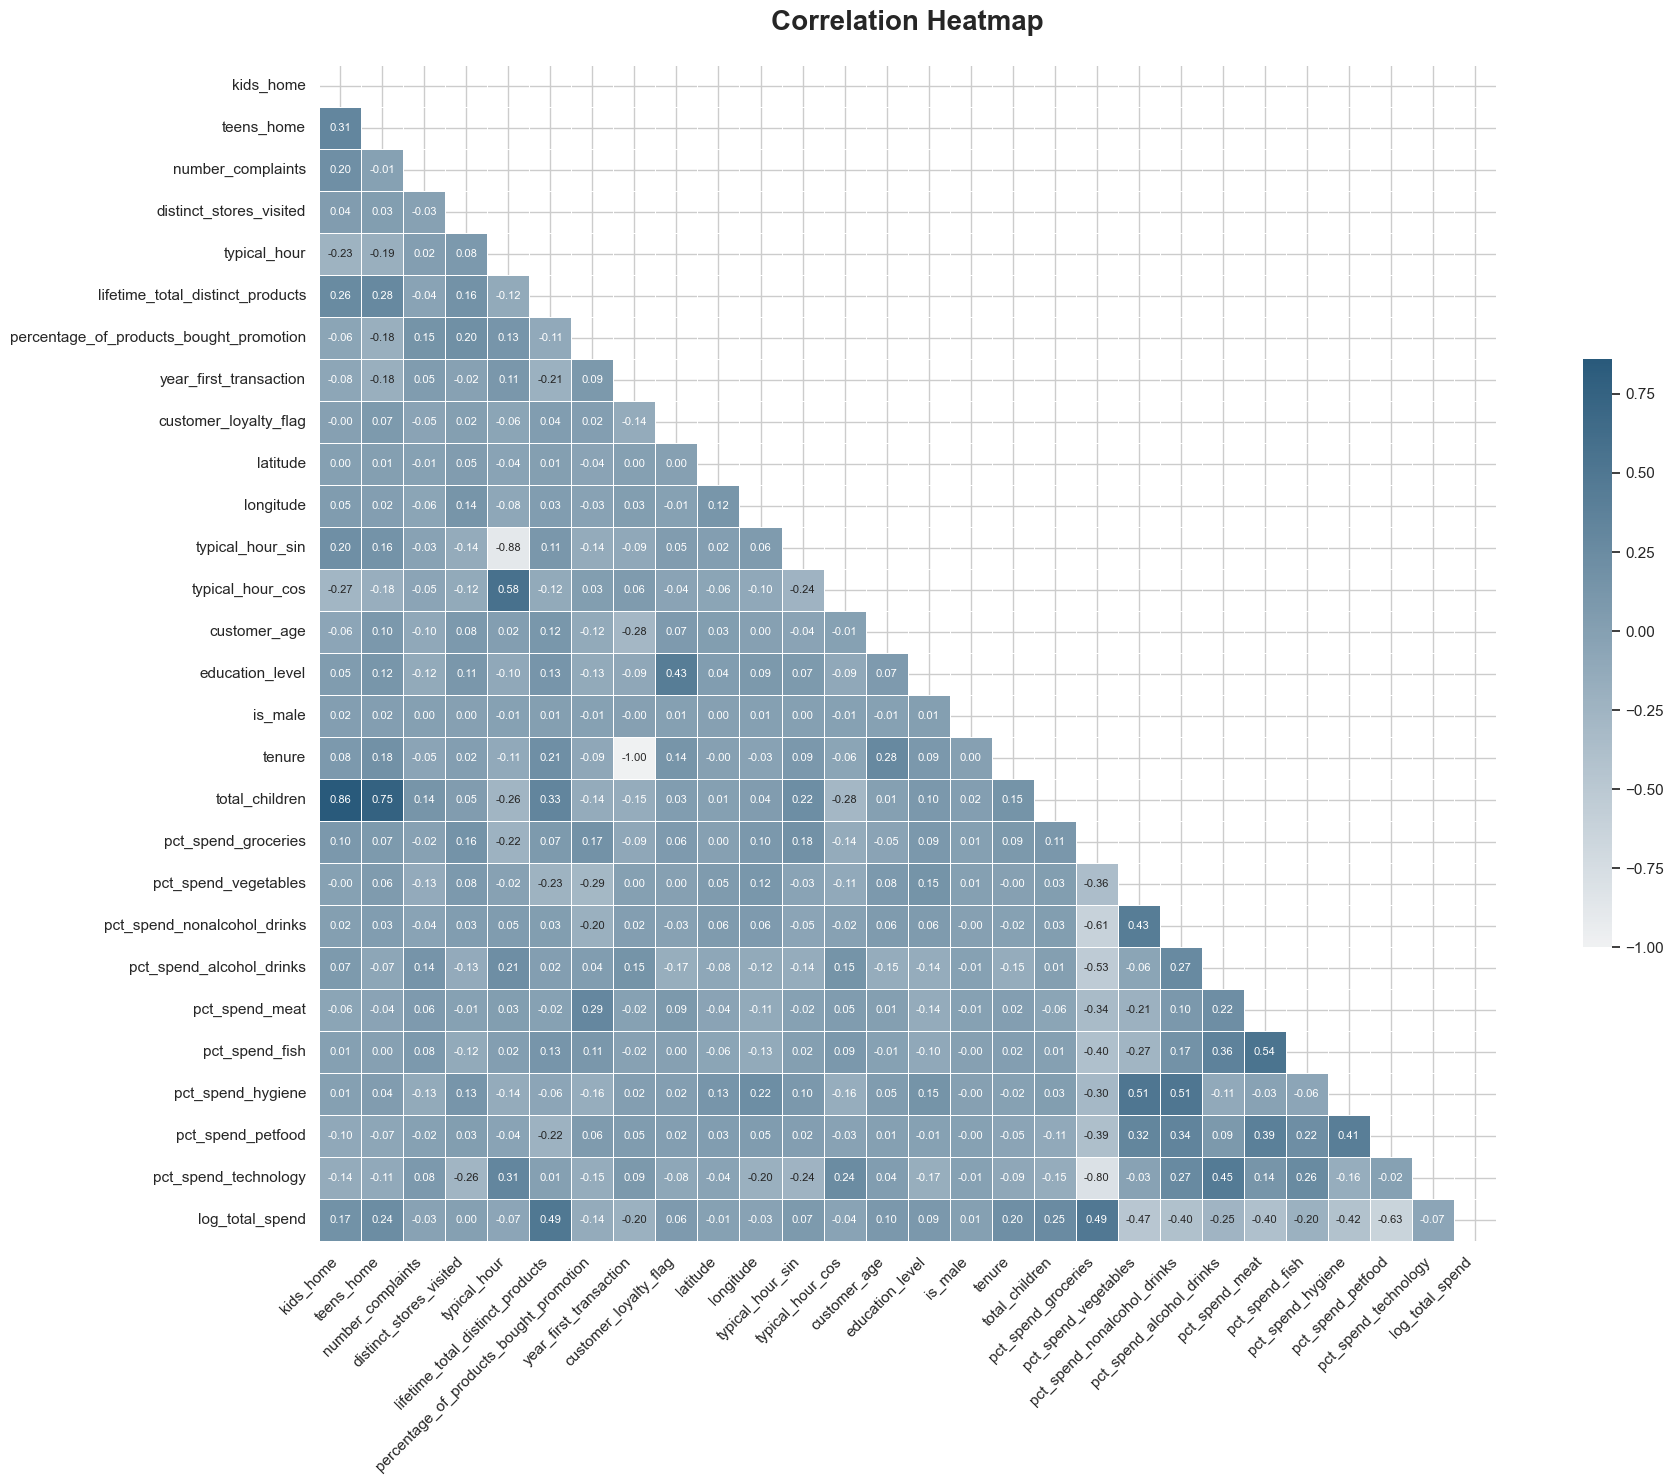

,Variable 1,Variable 2,Correlation
3,tenure,year_first_transaction,1.000000
2,typical_hour_sin,typical_hour,0.877294
0,total_children,kids_home,0.860203
4,pct_spend_technology,pct_spend_groceries,0.800819
1,total_children,teens_home,0.753155


In [24]:
num_cols = ci_clean.select_dtypes(include=np.number).columns
utils.cor_heatmap(ci_clean[num_cols].corr())
utils.get_high_correlations(ci_clean, threshold=0.7)

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #0047AB;"><h3><b>9. Export</b></h3></div>

<div style="background-color:#F9FCFF; padding:16px; border-radius:10px;">We drop columns that should not drive distance-based clustering (raw year, kids/teens already folded into <code>total_children</code>, the linear hour replaced by its cyclic version). The <b>unscaled</b> file is what the clustering notebook reads — scaling happens there so the scaler comparison is fair and reproducible.</div>

In [25]:
columns_to_drop = ["year_first_transaction", "kids_home", "teens_home", "typical_hour"]
binary_features = ["customer_loyalty_flag", "is_male", "education_level"]

unscaled_df = utils.build_clustering_dataset(
    ci_clean, columns_to_drop=columns_to_drop, binary_features=binary_features)

print("Export shape:", unscaled_df.shape)
unscaled_df.head()

Export shape: (33038, 24)


,number_complaints,distinct_stores_visited,lifetime_total_distinct_products,percentage_of_products_bought_promotion,customer_loyalty_flag,latitude,longitude,typical_hour_sin,typical_hour_cos,customer_age,education_level,is_male,tenure,total_children,pct_spend_groceries,pct_spend_vegetables,pct_spend_nonalcohol_drinks,pct_spend_alcohol_drinks,pct_spend_meat,pct_spend_fish,pct_spend_hygiene,pct_spend_petfood,pct_spend_technology,log_total_spend
customer_id,,,,,,,,,,,,,,,,,,,,,,,,
3,1,3,189,0.631599,1,38.794428,-9.215739,0.151764,-4.063504e-01,56.0,15,0,6,2,0.631038,0.020065,0.017375,0.009521,0.001506,0.011458,0.029693,0.020656,0.258687,9.830433
4,0,2,130,0.149890,1,38.751711,-9.179611,-0.148236,-7.395953e-01,50.0,15,0,13,1,0.676815,0.099442,0.026343,0.004695,0.002125,0.000741,0.092918,0.032867,0.064054,9.915120
5,0,2,81,0.069126,0,38.780678,-9.160656,0.258819,-9.659258e-01,54.0,17,1,21,0,0.797929,0.035694,0.006496,0.007589,0.081356,0.017557,0.032607,0.014277,0.006496,9.651816
7,2,1,92,0.253609,1,38.739548,-9.148679,-1.000000,-1.665335e-16,43.0,12,1,5,0,0.501137,0.005618,0.050629,0.075776,0.065008,0.072432,0.032437,0.012306,0.184658,9.612667
8,2,1,6,0.186569,1,38.733071,-9.188188,-0.965926,-2.588190e-01,56.0,12,1,5,0,0.385826,0.015959,0.024862,0.030154,0.044853,0.042627,0.012473,0.018521,0.424726,10.077955


In [26]:
dropped = utils.validate_customer_coverage(unscaled_df, ci_original)
assert len(dropped) == 0, f"{len(dropped)} customers were lost!"
print("All customers retained.")

Original: 33,038  |  Remaining: 33,038  |  Lost: 0
All customers retained.


In [27]:
out_dir = "../datasets" if os.path.isdir("../datasets") else "datasets"
utils.export_clustering_data(
    scaled_df  = unscaled_df,   # export once; clustering notebook scales internally
    unscaled_df = unscaled_df,
    output_dir  = out_dir,
    scaled_name  = "info_clustering_ready.csv",
    unscaled_name = "info_clustering_unscaled.csv")

Scaled   → ../datasets/info_clustering_ready.csv
Unscaled → ../datasets/info_clustering_unscaled.csv
